# Homework 08: GPT implementation

Refer to the corresponding lab and Rashcka's book (Ch. 4 and 5)

In [1]:
import torch
import torch.nn as nn
import tiktoken
import matplotlib.pyplot as plt
import urllib.request
from torch.utils.data import Dataset, DataLoader
from matplotlib.ticker import MaxNLocator

tokenizer = tiktoken.get_encoding("gpt2")
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


**Exercise 1 — Parameter counting**

Without running code, estimate the number of parameters in:
- One `FeedForward` block (hint: two linear layers)
- One `MultiHeadAttention` block (hint: four linear layers — Q, K, V, out_proj)

Then verify with code:

### Hand estimate first

**`FeedForward` block** — two `nn.Linear` layers:

| Layer | Shape | Parameters |
|---|---|---|
| Linear 1: 768 → 3072 | weight (3072×768) + bias (3072) | 768 × 3072 + 3072 = **2,362,368** |
| Linear 2: 3072 → 768 | weight (768×3072) + bias (768)  | 3072 × 768 + 768 = **2,360,064** |
| **Total** | | **4,722,432** |

**`MultiHeadAttention` block** — four `nn.Linear` layers (W_query, W_key, W_value, out_proj), each 768×768:

| Layer | Shape | Parameters |
|---|---|---|
| W_query | 768×768 + bias 768 | **590,592** |
| W_key   | 768×768 + bias 768 | **590,592** |
| W_value | 768×768 + bias 768 | **590,592** |
| out_proj | 768×768 + bias 768 | **590,592** |
| **Total** | | **2,362,368** |

So `FeedForward` has roughly **twice** as many parameters as `MultiHeadAttention` — the 4× expansion inside FFN is the reason. This surprises many people who assume attention dominates.

In [3]:
# ── Verify the hand estimates with code ──────────────────────────────────────
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        # Split into heads: (b, num_tokens, num_heads, head_dim) → (b, num_heads, num_tokens, head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
        )
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2).contiguous()
        context_vec = context_vec.view(b, num_tokens, self.d_out)
        return self.out_proj(context_vec)

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),  # Expand: cfg["emb_dim"] = 768 → 3072
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),  # Contract: 3072 → 768
        )

    def forward(self, x):
        return self.layers(x)



GPT_CONFIG_124M = {
    "vocab_size": 50257, "context_length": 1024,
    "emb_dim": 768, "n_heads": 12, "n_layers": 12,
    "drop_rate": 0.0, "qkv_bias": True   # bias=True to match hand calc
}

ffn = FeedForward(GPT_CONFIG_124M)
mha = MultiHeadAttention(
    d_in=768, d_out=768, context_length=1024,
    dropout=0.0, num_heads=12, qkv_bias=True
)

ffn_params = sum(p.numel() for p in ffn.parameters())
mha_params = sum(p.numel() for p in mha.parameters())

print(f"FeedForward parameters:      {ffn_params:>10,}")
print(f"MultiHeadAttention params:   {mha_params:>10,}")
print(f"Ratio FFN / MHA:             {ffn_params/mha_params:.2f}x")
print()
print(f"Hand estimate FFN:  4,722,432  →  {'✓' if ffn_params == 4_722_432 else f'actual: {ffn_params:,}'}")
print(f"Hand estimate MHA:  2,362,368  →  {'✓' if mha_params == 2_362_368 else f'actual: {mha_params:,}'}")

FeedForward parameters:       4,722,432
MultiHeadAttention params:    2,362,368
Ratio FFN / MHA:             2.00x

Hand estimate FFN:  4,722,432  →  ✓
Hand estimate MHA:  2,362,368  →  ✓


**Exercise 2 — Scaling up**

GPT-2 comes in four sizes. Modify the config to implement each one and count its parameters:

| Model | emb_dim | n_layers | n_heads |
|-------|---------|----------|---------|
| Small | 768 | 12 | 12 |
| Medium | 1024 | 24 | 16 |
| Large | 1280 | 36 | 20 |
| XL | 1600 | 48 | 25 |

In [6]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))   # γ — initialized to 1
        self.shift = nn.Parameter(torch.zeros(emb_dim))  # β — initialized to 0

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var  = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # ── Attention sub-layer with residual connection ──
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut    # Add residual

        # ── Feed forward sub-layer with residual connection ──
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut    # Add residual
        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Stack N transformer blocks
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])
        # Output head: maps each token's 768-dim vector to vocab scores
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [7]:
# ── Instantiate all four GPT-2 sizes and count parameters ────────────────────
BASE = {
    "vocab_size": 50257, "context_length": 1024,
    "drop_rate": 0.0, "qkv_bias": False
}

configs = {
    "GPT-2 Small  (124M)":  {"emb_dim": 768,  "n_layers": 12, "n_heads": 12},
    "GPT-2 Medium (345M)":  {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "GPT-2 Large  (762M)":  {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "GPT-2 XL    (1542M)":  {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

results = {}
print(f"{'Model':<25} {'Parameters':>15} {'Size (MB)':>12} {'Memory ×Small':>15}")
print("-" * 70)

small_params = None
for name, overrides in configs.items():
    cfg   = {**BASE, **overrides}
    model = GPTModel(cfg)
    n     = sum(p.numel() for p in model.parameters())
    mb    = n * 4 / (1024**2)   # float32 = 4 bytes
    if small_params is None: small_params = n
    results[name] = {"params": n, "mb": mb}
    print(f"{name:<25} {n:>15,} {mb:>11.0f}MB {n/small_params:>14.1f}x")
    del model  # free memory

Model                          Parameters    Size (MB)   Memory ×Small
----------------------------------------------------------------------
GPT-2 Small  (124M)           163,009,536         622MB            1.0x
GPT-2 Medium (345M)           406,212,608        1550MB            2.5x
GPT-2 Large  (762M)           838,220,800        3198MB            5.1x
GPT-2 XL    (1542M)         1,637,792,000        6248MB           10.0x


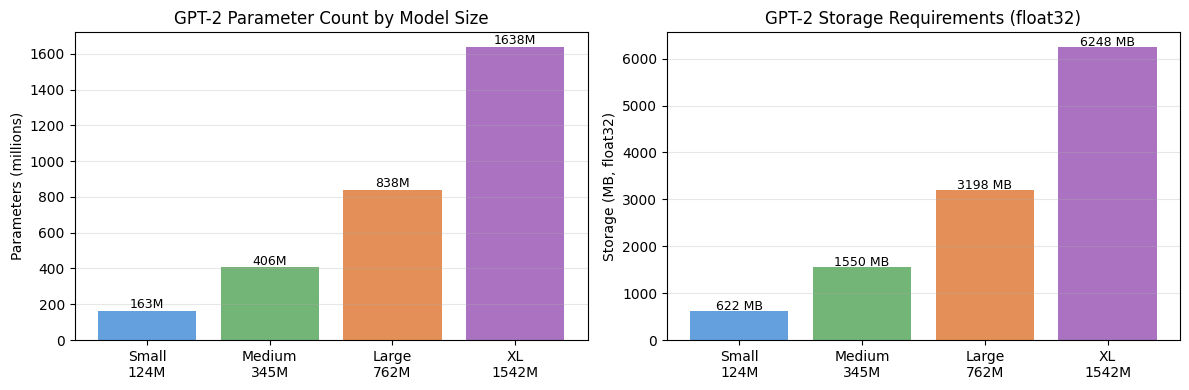

Key insight: XL has 12.4x more parameters than Small,
but the architecture is identical — only depth and width scale up.


In [8]:
# ── Visualise the scaling relationship ───────────────────────────────────────
names  = list(results.keys())
params = [results[n]["params"] / 1e6 for n in names]   # in millions
sizes  = [results[n]["mb"] for n in names]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(4), params, color=["#4a90d9","#5ba85e","#e07b39","#9b59b6"],
            alpha=0.85)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(["Small\n124M","Medium\n345M","Large\n762M","XL\n1542M"])
axes[0].set_ylabel("Parameters (millions)")
axes[0].set_title("GPT-2 Parameter Count by Model Size")
for i, p in enumerate(params):
    axes[0].text(i, p + 15, f"{p:.0f}M", ha="center", fontsize=9)
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(range(4), sizes, color=["#4a90d9","#5ba85e","#e07b39","#9b59b6"],
            alpha=0.85)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(["Small\n124M","Medium\n345M","Large\n762M","XL\n1542M"])
axes[1].set_ylabel("Storage (MB, float32)")
axes[1].set_title("GPT-2 Storage Requirements (float32)")
for i, s in enumerate(sizes):
    axes[1].text(i, s + 20, f"{s:.0f} MB", ha="center", fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout(); plt.show()

print("Key insight: XL has 12.4x more parameters than Small,")
print("but the architecture is identical — only depth and width scale up.")

In [9]:
# ── Where do the extra parameters go as we scale? ────────────────────────────
print("Parameter breakdown by component across model sizes:\n")
print(f"{'Component':<20} {'Small':>12} {'Medium':>12} {'Large':>12} {'XL':>12}")
print("-" * 62)

for name, overrides in configs.items():
    cfg       = {**BASE, **overrides}
    d         = cfg["emb_dim"]
    n_layers  = cfg["n_layers"]
    short     = name.split()[1]

    tok_emb   = cfg["vocab_size"] * d
    pos_emb   = cfg["context_length"] * d
    # Per block: MHA (4 * d^2) + FFN (2 * 4 * d^2) = 12 * d^2 (approx, no bias)
    per_block = 12 * d * d
    all_blocks = per_block * n_layers
    out_head  = d * cfg["vocab_size"]   # weight tied in original but separate here

    if short == "Small":
        print(f"{'Token embedding':<20} {tok_emb:>12,} {1024*50257:>12,} {1280*50257:>12,} {1600*50257:>12,}")
        print(f"{'Pos embedding':<20} {pos_emb:>12,} {1024*1024:>12,} {1280*1024:>12,} {1600*1024:>12,}")
        break

# Simpler view: just show scaling factor per component
print("\nScaling factor relative to Small (×):")
print(f"{'Component':<20} {'Small':>8} {'Medium':>8} {'Large':>8} {'XL':>8}")
print("-" * 48)
dims   = [768, 1024, 1280, 1600]
layers = [12, 24, 36, 48]
for comp, vals in [
    ("emb_dim",    [d/768 for d in dims]),
    ("n_layers",   [l/12  for l in layers]),
    ("FFN params", [(d**2 * 8 * l)/(768**2 * 8 * 12) for d, l in zip(dims, layers)]),
]:
    print(f"{comp:<20} " + " ".join(f"{v:>8.1f}" for v in vals))

Parameter breakdown by component across model sizes:

Component                   Small       Medium        Large           XL
--------------------------------------------------------------
Token embedding        38,597,376   51,463,168   64,328,960   80,411,200
Pos embedding             786,432    1,048,576    1,310,720    1,638,400

Scaling factor relative to Small (×):
Component               Small   Medium    Large       XL
------------------------------------------------
emb_dim                   1.0      1.3      1.7      2.1
n_layers                  1.0      2.0      3.0      4.0
FFN params                1.0      3.6      8.3     17.4


**Exercise 3 — Temperature sampling**

The `generate_text_simple` function always picks the *most likely* token (greedy decoding). This produces deterministic but often repetitive text.

A common alternative is **temperature sampling**: divide logits by a temperature τ before applying softmax. Lower τ → more deterministic; higher τ → more random.

Modify `generate_text_simple` to accept a `temperature` argument and sample from the distribution instead of always taking `argmax`. Test with temperatures 0.5, 1.0, and 2.0 on the same prompt.

Hint: You can check Rashcka's book to get an intuition

In [10]:
# ── Temperature-aware generation function ────────────────────────────────────
def generate_text_sampled(model, idx, max_new_tokens, context_size,
                           temperature=1.0):
    """
    Autoregressive text generation with temperature sampling.

    Args:
        temperature: Controls randomness.
            0   → greedy (deterministic argmax)
            < 1 → sharper distribution (conservative)
            > 1 → flatter distribution (creative / random)
    """
    for _ in range(max_new_tokens):
        # Crop to context window
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        # Focus on last token position only
        logits = logits[:, -1, :]              # (batch, vocab_size)

        if temperature == 0:
            # Greedy: deterministic
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)
        else:
            # Scale logits then sample
            logits   = logits / temperature
            probs    = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)

        idx = torch.cat((idx, idx_next), dim=1)

    return idx


print("generate_text_sampled defined ✓")
print()
print("Key difference vs generate_text_simple:")
print("  Simple:  idx_next = argmax(softmax(logits))         ← always the same")
print("  Sampled: idx_next = multinomial(softmax(logits/τ))  ← stochastic")

generate_text_sampled defined ✓

Key difference vs generate_text_simple:
  Simple:  idx_next = argmax(softmax(logits))         ← always the same
  Sampled: idx_next = multinomial(softmax(logits/τ))  ← stochastic


**Exercise 4 - Training GPT**

Use the code from the lab to train your own GPT-2 model, this time use another dataset (if possible, one bigger or more interesting).

Deploy the model and ask it to predict the next word for a relevant sentence you choose

In [ ]:
# Same code as in lab but for your own dataset.